In [40]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("C:\\Users\\suhas\\Downloads\\mpg.csv")


In [ ]:
df = df[['horsepower', 'mpg']]
df = df.dropna()

In [31]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna()

In [ ]:
X = df[['horsepower']]
y = df['mpg']

In [27]:
print("Shape of X:", X.shape)

Shape of X: (392, 1)


In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, Y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


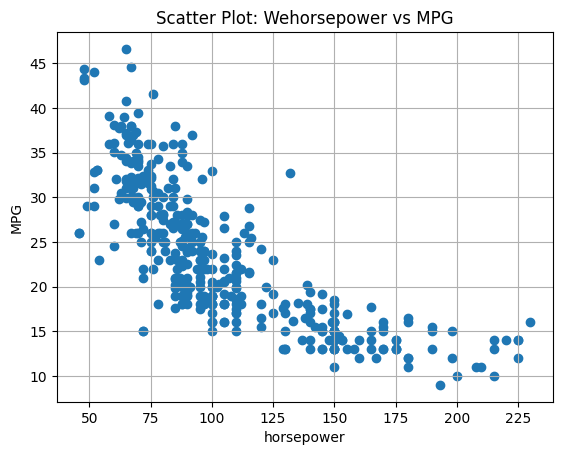

In [34]:
plt.figure()
plt.scatter(df['horsepower'], df['mpg'])
plt.xlabel("horsepower")
plt.ylabel("MPG")
plt.title("Scatter Plot: Wehorsepower vs MPG")
plt.grid(True)
plt.show()

In [35]:
print(df.isnull().sum())


horsepower    0
mpg           0
dtype: int64


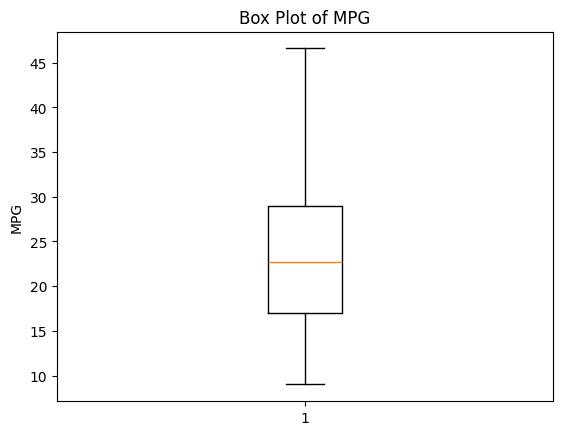

In [36]:
plt.figure()
plt.boxplot(df['mpg'])

plt.title("Box Plot of MPG")
plt.ylabel("MPG")

plt.show()


In [ ]:
m = np.sum((X - X.mean()) * (y - y.mean())) / np.sum((X - X.mean())**2)

b = y.mean() - m * X.mean()

print("Formula Method")
print("Slope:", m)
print("Intercept:", b)


Formula Method
Slope: 0.0
Intercept: horsepower    23.445918
dtype: float64


In [41]:
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)


            horsepower       mpg
horsepower    1.000000 -0.778427
mpg          -0.778427  1.000000


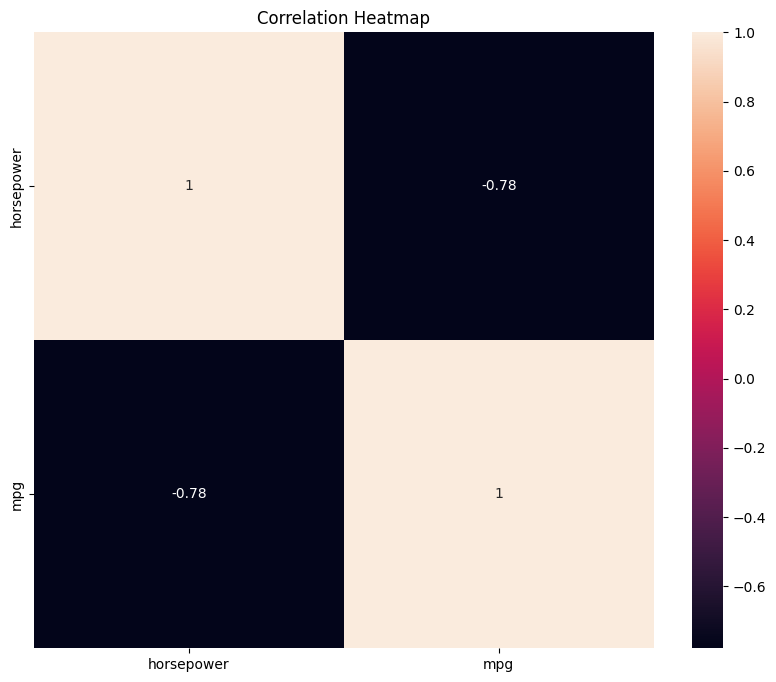

In [42]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True)

plt.title("Correlation Heatmap")
plt.show()


In [43]:
df.describe()

,horsepower,mpg
count,392.000000,392.000000
mean,104.469388,23.445918
std,38.491160,7.805007
min,46.000000,9.000000
25%,75.000000,17.000000
50%,93.500000,22.750000
75%,126.000000,29.000000
max,230.000000,46.600000


In [44]:
df.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   horsepower  392 non-null    float64
 1   mpg         392 non-null    float64
dtypes: float64(2)
memory usage: 9.2 KB


In [46]:
df_sorted = df.sort_values(by='horsepower')

Text(0.5, 1.0, 'Horsepower vs MPG (Regression Line)')

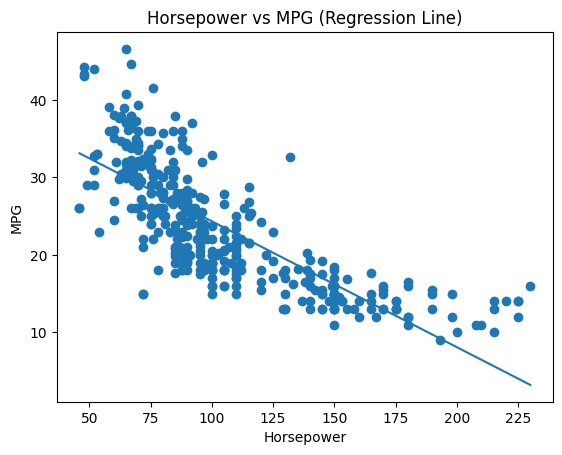

In [47]:
plt.figure()
plt.scatter(df_sorted['horsepower'], df_sorted['mpg'])
plt.plot(df_sorted['horsepower'], model.predict(df_sorted[['horsepower']]))

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG (Regression Line)")